In [11]:
import pandas as pd                 # Manejo de Dataframes
import matplotlib.pyplot as plt     # Gráficos
from PIL import Image, ImageOps     # Gráficos de Imágenes
import numpy as np                  # Números en general

# Librerías para definir el modelo de IA
from keras.models import Model
from keras.layers import Conv1D, Dense, Flatten, Input, Add, Dropout, ReLU, BatchNormalization, Lambda
import tensorflow as tf

# Librearías para definir el entrenamiento de la IA
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, History

from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.metrics import MeanAbsoluteError

# Librerías para Separación de Datos
from sklearn.model_selection import train_test_split

# Tipos de datos
from typing import Tuple
from matplotlib.axes import Axes
from matplotlib.figure import Figure

# Variables

In [12]:
# Path absoluto a direcciones de informacion
path_ds = r"E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\merged\dataset_corr.parquet"

# Variables de entrenamiento de la IA
callbacks = [EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=False
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6
        ),
        ModelCheckpoint(
            filepath="mejor_modelo.keras",
            monitor="val_loss",
            save_best_only=True
        )
]

epochs = 80
batch_size = 32

test_split = .1
val_split = .15     # con respecto al trainval, no al total 

# Funciones

### Funciones del Modelo

Funciones para definir el modelo de IA a realizar y entrenar. También posee funciones para obtener de un dataframe las variables de entrada del modelo

In [13]:
def resnet_block(x, filters, kernel_size, dilatation=1):
    shortcut = x

    # Conv 1
    x = Conv1D(filters, kernel_size, padding="same", dilation_rate=dilatation, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Conv 2
    x = Conv1D(filters, kernel_size, padding="same", dilation_rate=dilatation, use_bias=False)(x)
    x = BatchNormalization()(x)

    # Proyección del shortcut si cambian los canales
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Suma residual + activación final
    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

def internal_block(x, filters, kernel_size):
    shortcut = x
    x = Conv1D(filters, kernel_size, padding="same", activation=None)(x)
    x = Conv1D(filters, kernel_size, padding="same", activation=None)(x)

    # Ajuste del shortcut si cambia el número de filtros
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D( filters, 1, padding="same", activation=None)(shortcut)
    x = Add()([x, shortcut])

    return x

def init_model(seq_len=61, cant_variables=3) -> Model:
    inp = Input(shape=(seq_len, cant_variables))

    #x = internal_block(inp, filters=32, kernel_size=5)   # Bloque 1
    #x = internal_block(x, filters=64, kernel_size=3)     # Bloque 2
    #x = internal_block(x, filters=64, kernel_size=3)     # Bloque 3
    x = resnet_block(inp, filters=32, kernel_size=5)   # Bloque 1
    x = resnet_block(x, filters=64, kernel_size=3)     # Bloque 2
    x = resnet_block(x, filters=64, kernel_size=3, dilatation=2)     # Bloque 3

    # Capa de salida
    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)
    #x = Dropout(0.3)(x)
    out = Dense(seq_len, activation="linear")(x)

    #x = Conv1D(64, 3, padding="same", activation="relu")(x)
    #out = Conv1D(1, 1, padding="same", activation="linear")(x)
    #out = Lambda(lambda t: tf.squeeze(t, axis=-1))(out)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(1e-3),
        loss=MeanSquaredError(),
        metrics=[MeanAbsoluteError()]
    )

    return model

def get_data(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    X = []
    Y = []
    angulos = np.arange(0, 181, 3) #/ 180

    for _, row in df.iterrows():
        us = row['ultrasonico']        
        ir = row['infrarrojo']         
        real = row['distancias_mapa']  
        kalman = row['kalman']
        # Entrada (61,4)
        entrada = np.column_stack([us, ir, angulos, kalman])  
        X.append(entrada)
        Y.append(real)

    return np.array(X), np.array(Y)

### Funciones de métricas

Creadas para poder comparar y visualizar resultados

In [14]:
def plot_history(history: History)->Tuple[Figure, Tuple[Axes, Axes]]:
    """
    Grafica el historial de entrenamiento de Keras en dos subplots:
    - Loss (train y val)
    - MAE (train y val, si existe)
    """

    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    ax_loss, ax_mae = axes

    # LOSS
    ax_loss.plot(history.history["loss"], label="Loss (train)")
    ax_loss.plot(history.history["val_loss"], label="Loss (val)")

    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title("Evolución del Loss")
    ax_loss.legend()
    ax_loss.grid(True)

    if "mean_absolute_error" in history.history:
        ax_mae.plot(history.history["mean_absolute_error"], label="MAE (train)")
        ax_mae.plot(history.history["val_mean_absolute_error"], label="MAE (val)")
        ax_mae.set_title("Evolución del MAE")
    else:
        ax_mae.text(0.5, 0.5, "MAE no disponible", ha='center', va='center')

    ax_mae.set_xlabel("Epoch")
    ax_mae.set_ylabel("MAE")
    ax_mae.legend()
    ax_mae.grid(True)

    plt.tight_layout()
    return fig, axes

def mae(y_true, y_pred):
    """Mean Absolute Error global para arrays (N, L)."""
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    """Mean Squared Error global."""
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    """Root Mean Squared Error global."""
    return np.sqrt(mse(y_true, y_pred))

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (ignora ceros en y_true)."""
    y_true = y_true.astype(float)
    mask = np.abs(y_true) > 1e-8
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def metrics(y_true, y_pred):
    """Retorna todas las métricas en un diccionario."""
    return {
        "MAE": mae(y_true, y_pred),
        "MSE": mse(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE(%)": mape(y_true, y_pred),
    }


### Funciones del dataset

Funciones sencillas para poder graficar los datos y visualizarlos mejor

TODO Pasar esto a una lib


In [15]:
def clean_dataframe(df) -> pd.DataFrame:
    """
    Limpia filas inválidas del dataset.

    Conserva únicamente filas donde:
    - angulo existe
    - ultrasonico existe
    - infrarrojo existe
    - distancias_mapa existe
    - todos tienen la misma longitud
    """

    required_cols = ["angulo", "ultrasonico", "infrarrojo", "distancias_mapa", "kalman"]
    valid_types = (list, np.ndarray)

    def valid_row(row):
        for col in required_cols:
            if not isinstance(row[col], valid_types):
                return False
        n = len(row["angulo"])

        return (
            len(row["ultrasonico"]) == n and
            len(row["infrarrojo"]) == n and
            len(row["distancias_mapa"]) == n and
            len(row["kalman"]) == n
        )

    df = df[df.apply(valid_row, axis=1)].copy()
    return df.reset_index()

def plot_polar(angles_deg, values, title=None, ax:plt.Axes=None, 
               threshold=None, threshold_color="red", **plot_kwargs):
    if ax is None:
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection="polar")
    else:
        fig = ax.figure

    angles_rad = np.deg2rad(angles_deg)
    ax.plot(angles_rad, values, **plot_kwargs)

    # Limite
    if threshold is not None:
        full_circle = np.linspace(0, 2*np.pi, 400)
        r_max = max(max(values), threshold * 1.2)
        ax.fill_between(full_circle, threshold, r_max, color=threshold_color, alpha=0.2)
        ax.plot(full_circle, np.full_like(full_circle, threshold), color=threshold_color, linestyle="--", linewidth=1.5)
        ax.set_ylim(0, threshold * 1.1)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    if title:
        ax.set_title(title)

    ax.grid(True)
    return fig, ax

def plot_all_scans(df: pd.DataFrame, idx, mode="side", threshold = 500):
    """
    mode="side": 3 subplots polares, lado a lado
    mode="overlay": 3 curvas superpuestas en 1 solo polar
    """

    row = df.iloc[idx]
    ang = row["angulo"]
    us  = row["ultrasonico"]
    ir  = row["infrarrojo"]
    ang_map = row.get("angulos_mapa")
    dist_map = row.get("distancias_mapa")
    
    scan_id = row.get("id", idx)

    # --- MODO SUBPLOTS LATERALES ---
    if mode == "side":
        fig = plt.figure(figsize=(18,6))
        
        # Ultrasonido
        ax1 = fig.add_subplot(131, projection="polar")
        plot_polar(ang, us, title="Ultrasonido", ax=ax1, threshold=threshold)

        # Infrarrojo
        ax2 = fig.add_subplot(132, projection="polar")
        plot_polar(ang, ir, title="Infrarrojo", ax=ax2, threshold=threshold)

        # Imagen procesada
        ax3 = fig.add_subplot(133, projection="polar")
        plot_polar(ang_map, dist_map, title="Foto procesada", ax=ax3, threshold=threshold)

        fig.suptitle(f"Medición ID {scan_id}", fontsize=14)
        plt.tight_layout()
        plt.show()
        return fig

    # --- MODO SUPERPUESTO ---
    elif mode == "overlay":
        fig = plt.figure(figsize=(7,7))
        ax = fig.add_subplot(111, projection="polar")

        plot_polar(ang, us,  ax=ax, label="Ultrasonido", threshold=threshold)
        plot_polar(ang, ir,  ax=ax, label="Infrarrojo", threshold=threshold)
        plot_polar(ang_map, dist_map, ax=ax, label="Distancia mapa", threshold=threshold)

        ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
        ax.set_title(f"Medición ID {scan_id} — Comparación")

        plt.show()
        return fig

    else:
        raise ValueError('mode debe ser "side" o "overlay"')
    

# Carga del Dataset

## Carga del Dataset en Python

Se carga la carpeta con los .csv y se limpia el dataframe para poder ser utilizado luego.

In [16]:
# Cargo el dataframe
df = pd.read_parquet(path_ds)

# Limpio el dataframe
df = clean_dataframe(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            389 non-null    int64  
 1   id               389 non-null    int64  
 2   fecha            389 non-null    str    
 3   imagen_path      0 non-null      float64
 4   angulo           389 non-null    object 
 5   ultrasonico      389 non-null    object 
 6   infrarrojo       389 non-null    object 
 7   kalman           389 non-null    object 
 8   angulos_mapa     389 non-null    object 
 9   distancias_mapa  389 non-null    object 
 10  image_path       389 non-null    str    
dtypes: float64(1), int64(2), object(6), str(2)
memory usage: 75.4+ KB


Chequeo del dataset

In [17]:
#df

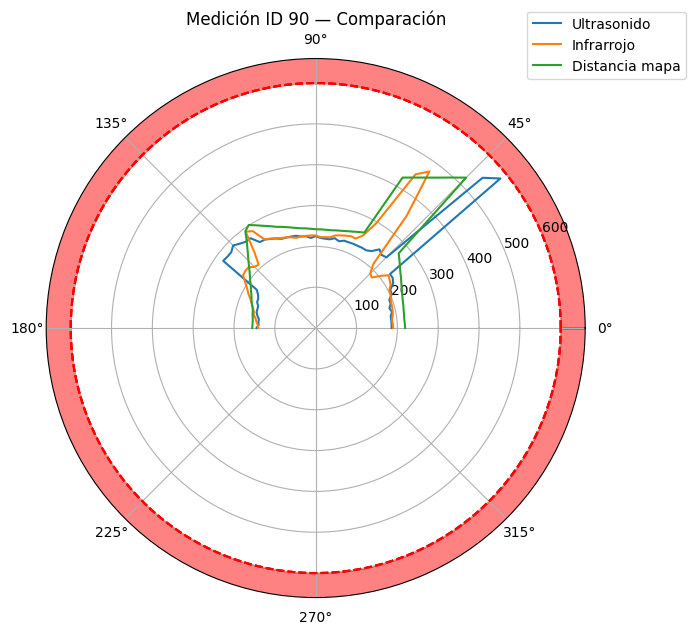

In [18]:
idx = 83
plot_all_scans(df, idx, mode='overlay', threshold=600);

# Entrenamiento de IA

In [19]:
X, Y = get_data(df)
indices = df.index.to_numpy()

X_trainval, X_test, Y_trainval, Y_test, idx_trainval, idx_test = train_test_split(
    X, Y, indices,
    test_size=test_split,
    shuffle=True,
    random_state=21
)


## Entrenamiento final

In [20]:
model_final = init_model(seq_len=X.shape[1], cant_variables=X.shape[2])
model_final.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 61, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 61, 32)    │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 61, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 61, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 61, 32)    │      5,120 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 61, 32)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 32)    │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 61, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 61, 32)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 61, 64)    │      6,144 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 61, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 61, 64)    │     12,288 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 61, 64)    │      2,048 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 64)    │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 61, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 61, 64)    │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 61, 64)    │     12,288 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 560,317 (2.14 MB)

 Trainable params: 559,485 (2.13 MB)

 Non-trainable params: 832 (3.25 KB)

In [21]:
history = model_final.fit(
    X_trainval,
    Y_trainval,
    validation_split=val_split,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks
)


Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 108078.8594 - mean_absolute_error: 301.1310 - val_loss: 78281.0625 - val_mean_absolute_error: 239.8487 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 65634.8125 - mean_absolute_error: 221.6808 - val_loss: 39837.6133 - val_mean_absolute_error: 157.7948 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 19931.5215 - mean_absolute_error: 107.4032 - val_loss: 32796.1641 - val_mean_absolute_error: 143.5158 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 10746.5029 - mean_absolute_error: 83.7575 - val_loss: 36586.9258 - val_mean_absolute_error: 156.8063 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8218.7676 - mean_absolute_error: 67.3977 - val_loss: 37364.0625 - val_mean_absolute_error: 157.8690 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 7320.1919 - mean_

# Verificacion de resultados


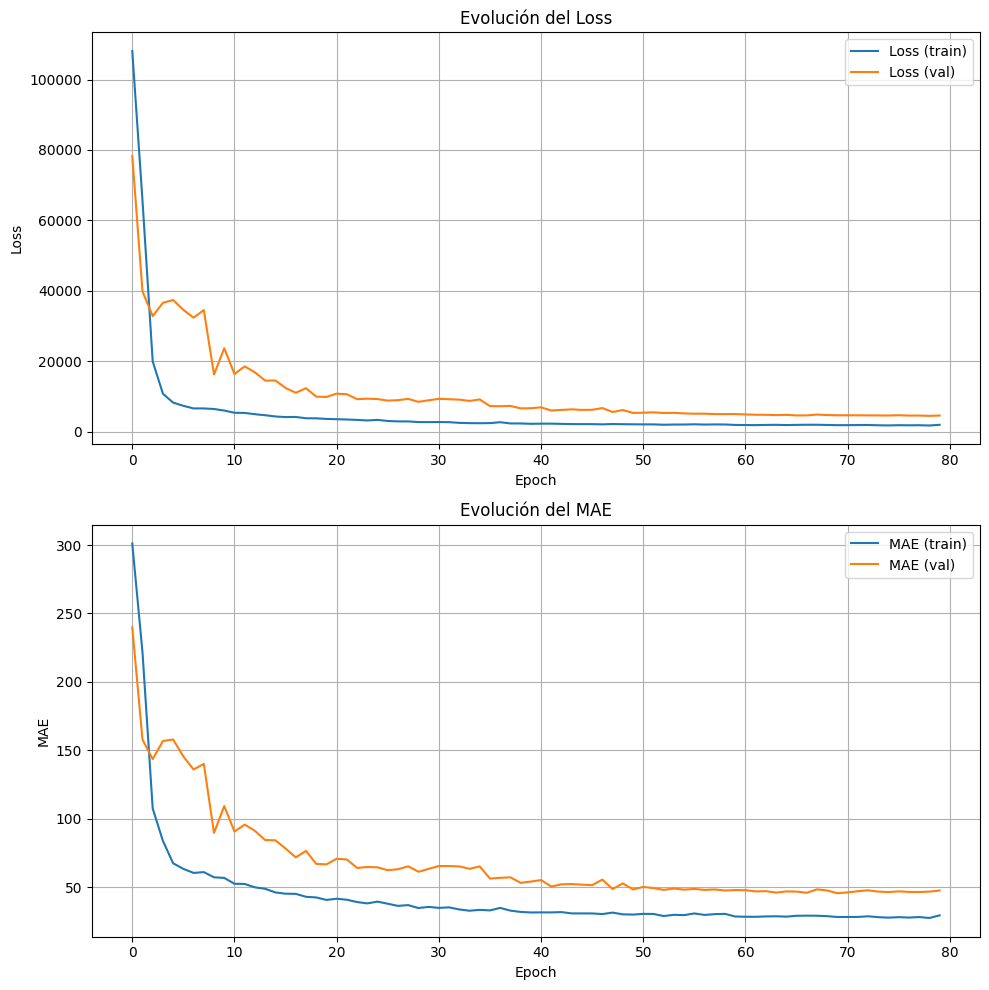

In [22]:
fig, ax = plot_history(history)
#ax[0].set_ylim(0, 10e3)
#ax[1].set_ylim(0, 10e3)
plt.show()


In [23]:
loss_test, mae_test = model_final.evaluate(X_test, Y_test, verbose=0)

print("\n=== RESULTADOS FINALES ===")
print(f'TRAIN Loss: {min(history.history['loss']):.4f}')
print(f'TRAIN MAE: {min(history.history['mean_absolute_error']):.4f}\n')
print(f'VAL Loss: {min(history.history['val_loss']):.4f}')
print(f'VAL MAE: {min(history.history['val_mean_absolute_error']):.4f}\n')
print(f"TEST Loss: {loss_test:.4f}")
print(f"TEST MAE:  {mae_test:.4f}\n")




=== RESULTADOS FINALES ===
TRAIN Loss: 1730.5237
TRAIN MAE: 27.3923

VAL Loss: 4468.7109
VAL MAE: 45.4957

TEST Loss: 3068.0891
TEST MAE:  43.2358



In [24]:
X, Y = get_data(df) 
kalman = np.stack(df['kalman'].to_list())
img_path = df['image_path'].to_numpy()
pred = model_final.predict(X)
mask = Y <= 450

_aux = metrics(Y[mask], kalman[mask])
print("Métricas Globales Kalman:")
print(f'MAE:\t\t{_aux['MAE']:.4f}\nMSE:\t\t{_aux['MSE']:.4f}\nRMSE:\t\t{_aux['RMSE']:.4f}\nMAPE(%):\t{_aux['MAPE(%)']:.4f}')

_aux = metrics(Y[mask], pred[mask]) 
print("\nMétricas Globales IA:")
print(f'MAE:\t\t{_aux['MAE']:.4f}\nMSE:\t\t{_aux['MSE']:.4f}\nRMSE:\t\t{_aux['RMSE']:.4f}\nMAPE(%):\t{_aux['MAPE(%)']:.4f}')


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Métricas Globales Kalman:
MAE:		53.3740
MSE:		21042.4153
RMSE:		145.0600
MAPE(%):	19.4208

Métricas Globales IA:
MAE:		35.5366
MSE:		2067.5767
RMSE:		45.4706
MAPE(%):	15.1200


E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\images_raw\19.jpg


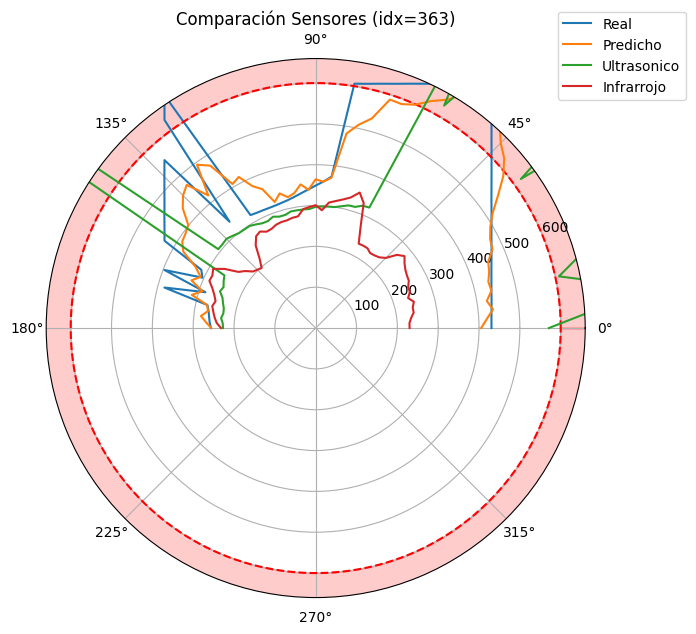

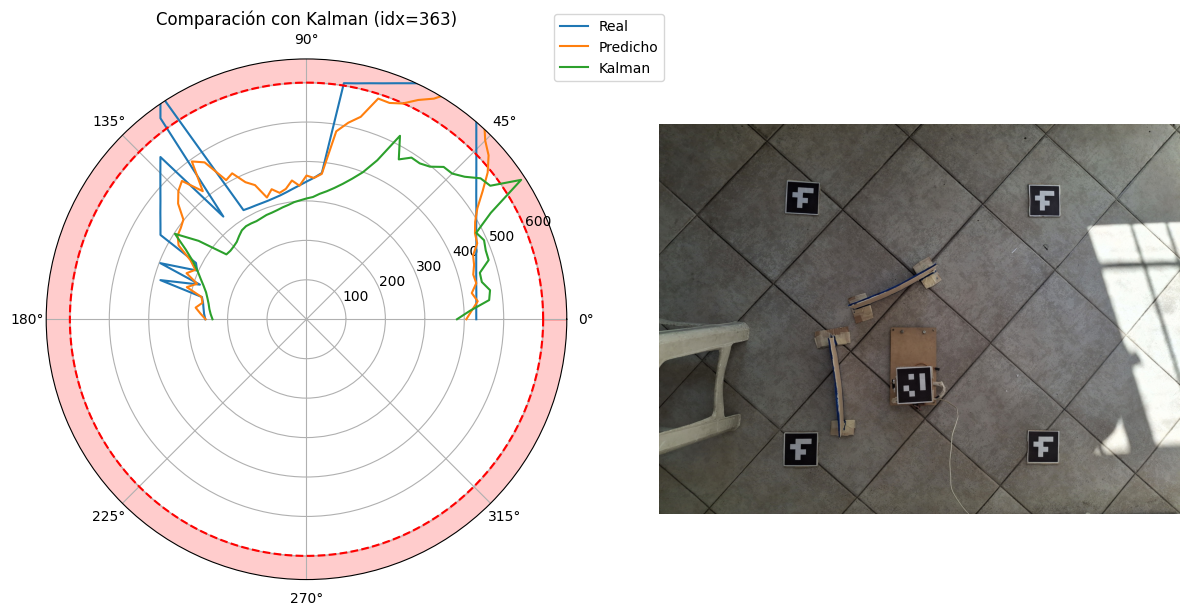

In [25]:
idx = np.random.randint(len(X))
us = X[idx][:, 0]
ir = X[idx][:, 1]

print(img_path[idx])

fig = plt.figure(figsize=(7,7))
ax_polar = fig.add_subplot(111, projection="polar")

angulos = np.linspace(0, 180, len(Y[idx]))
_, ax_polar = plot_polar(angulos, Y[idx], threshold=600, ax=ax_polar, label="Real")
_, ax_polar = plot_polar(angulos, pred[idx], ax=ax_polar, label="Predicho")
_, ax_polar = plot_polar(angulos, us, ax=ax_polar, label="Ultrasonico")
_, ax_polar = plot_polar(angulos, ir, ax=ax_polar, label="Infrarrojo")

ax_polar.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax_polar.set_title(f"Comparación Sensores (idx={idx})")
plt.show()

fig = plt.figure(figsize=(12,10))

# Prediccion
ax_polar = fig.add_subplot(1, 2, 1, projection="polar")
_, ax_polar = plot_polar(angulos, Y[idx], threshold=600, ax=ax_polar, label="Real")
_, ax_polar = plot_polar(angulos, pred[idx], ax=ax_polar, label="Predicho")
_, ax_polar = plot_polar(angulos, kalman[idx], ax=ax_polar, label="Kalman")

ax_polar.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax_polar.set_title(f"Comparación con Kalman (idx={idx})")

# Imagen
ax_img = fig.add_subplot(1, 2, 2)
img = Image.open(img_path[idx])
img = ImageOps.exif_transpose(img)   # Corrige la rotación automáticamente
img = np.array(img)

ax_img.imshow(img)
ax_img.axis("off")


plt.tight_layout()
plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


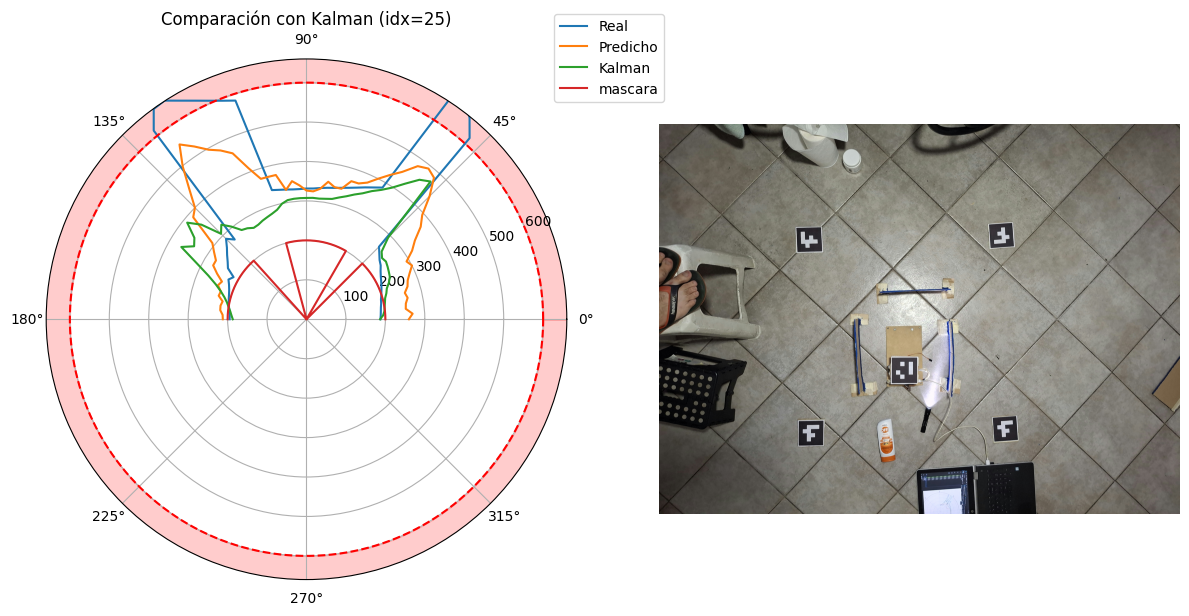

In [34]:
idx = np.random.randint(len(X_test))   
orig_idx = idx_test[idx]               

y_real = Y_test[idx]
y_pred = model_final.predict(X_test[idx:idx+1])[0]
y_kalman = df.loc[orig_idx, "kalman"]
img_path_test = df.loc[orig_idx, "image_path"]
mask = y_real <= 450

angulos = np.linspace(0, 180, len(Y[idx]))

us = X_test[idx][:, 0]
ir = X_test[idx][:, 1]


## Prueba random de test
fig = plt.figure(figsize=(12,10))

# Prediccion
ax_polar = fig.add_subplot(1, 2, 1, projection="polar")
_, ax_polar = plot_polar(angulos, y_real, threshold=600, ax=ax_polar, label="Real")
_, ax_polar = plot_polar(angulos, y_pred, ax=ax_polar, label="Predicho")
_, ax_polar = plot_polar(angulos, y_kalman, ax=ax_polar, label="Kalman")
_, ax_polar = plot_polar(angulos, 200*mask, ax=ax_polar, label="mascara")

ax_polar.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax_polar.set_title(f"Comparación con Kalman (idx={idx})")

# Imagen
ax_img = fig.add_subplot(1, 2, 2)
img = Image.open(img_path_test)
img = ImageOps.exif_transpose(img)   # Corrige la rotación automáticamente
img = np.array(img)

ax_img.imshow(img)
ax_img.axis("off")


plt.tight_layout()
plt.show()
